In [27]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("/user/leuven/386/vsc38672/DATA/pipeline/stats/bioinfo_method/hosp-admit/data/raw/HOSP_ADMIT.csv")
df.head()

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,...,fibr_ter_06,fibr_ter_07,fibr_ter_08,ALT_BLOOD,AST_BLOOD,L_BLOOD,ROE,TIME_B_S,NITR_S,OUTCOME
0,77.0,1,2.0,1,1,2,3,0,7.0,0,...,0,0,0,0.497883,0.290381,8.000000,16.000000,4.0,0,0
1,55.0,1,1.0,0,0,0,0,0,0.0,0,...,0,0,0,0.380000,0.180000,7.800000,3.000000,2.0,0,0
2,52.0,1,0.0,0,0,2,2,0,2.0,0,...,0,0,0,0.300000,0.110000,10.800000,10.480830,3.0,0,0
3,68.0,0,0.0,0,0,2,2,0,3.0,1,...,0,0,0,0.750000,0.370000,8.354193,16.070233,2.0,0,0
4,60.0,1,0.0,0,0,2,3,0,7.0,0,...,0,0,0,0.450000,0.220000,8.300000,14.058981,9.0,0,0


In [11]:
df.dtypes
df.nunique()

AGE           70
SEX            2
INF_ANAM       8
STENOK_AN      7
FK_STENOK      5
            ... 
L_BLOOD      299
ROE          261
TIME_B_S     135
NITR_S         2
OUTCOME        2
Length: 85, dtype: int64

<Axes: >

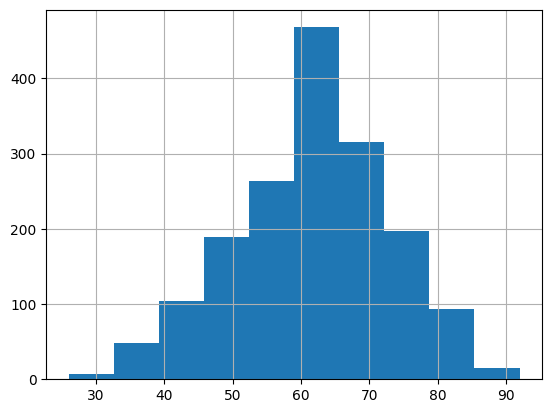

In [12]:
df["AGE"].hist()

In [15]:
missing_pct = (df.isna() | (df == 0)).mean() * 100
cols_over_10 = missing_pct[missing_pct > 10]

print(cols_over_10)

SEX            37.352941
INF_ANAM       62.352941
STENOK_AN      42.647059
FK_STENOK      42.529412
IBS_POST       25.588235
                 ...    
fibr_ter_06    99.470588
fibr_ter_07    99.647059
fibr_ter_08    99.882353
NITR_S         88.529412
OUTCOME        84.058824
Length: 77, dtype: float64


In [18]:
ecg_cols = df.filter(regex=r'^(n_r|n_p|ritm)').columns
ecg_df = df[ecg_cols]
ecg_df.head()

,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,...,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
corr_matrix = ecg_df.corr()

perfect_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) == 1:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            perfect_pairs.append((col1, col2))

print(perfect_pairs)

[]


outcome is 16% as dead

In [23]:
df["OUTCOME"].value_counts()

OUTCOME
0    1429
1     271
Name: count, dtype: int64

In [29]:
# 1. Isolate the target columns
ecg_cols = [c for c in df.columns if c.startswith(('n_r', 'n_p', 'ritm'))]

# 2. Check for zero variance (features where every row has the exact same value)
zero_var_cols = df[ecg_cols].columns[df[ecg_cols].nunique() <= 1].tolist()

# 3. Check for perfect collinearity (highly correlated features that crash unregularized models)
corr_matrix = df[ecg_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
collinear_cols = [column for column in upper_tri.columns if any(upper_tri[column] > 0.99)]
print(collinear_cols)

[]
